# Liver Patient Prediction

## Problem Statement

## Import Required Libraries

In [1]:

# Data manipulation
import numpy as np
import pandas as pd

#Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, recall_score, f1_score

In [2]:
# Load the dataset
column_names = [
    'Age',
    'Gender',
    'Total_Bilirubin',
    'Direct_Bilirubin',
    'Alkaline_Phosphotase',
    'Alamine_Aminotransferase',
    'Aspartate_Aminotransferase',
    'Total_Proteins',
    'Albumin',
    'Albumin_and_Globulin_Ratio',
    'Target'
]


df=pd.read_csv("Indian Liver Patient Dataset (ILPD).csv",header=None, names=column_names)
# Display first 5 rows
df.head()


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [3]:
df.tail()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Target
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1
582,38,Male,1.0,0.3,216,21,24,7.3,4.4,1.50,2


In [4]:
# Dataset Shape
df.shape

(583, 11)

In [5]:
df.columns

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Target'],
      dtype='object')

## Data Types Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Proteins              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Target                      583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


## Target Variable Analysis

In [7]:
df['Target'].value_counts()


Target
1    416
2    167
Name: count, dtype: int64

## Initial Observations
1) Dataset belongs to real-world healthcare
2) Contains clinical biochemical measurements
3) Outliers are expected in enzyme-related features
4) Data cleaning is essential before modeling

## Check for Missing Values

In [8]:
df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Proteins                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Target                        0
dtype: int64

In [9]:
## Handle Missing Values
df['Albumin_and_Globulin_Ratio'].fillna(df['Albumin_and_Globulin_Ratio'].median(),inplace=True)



/tmp/ipykernel_6067/52192812.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Albumin_and_Globulin_Ratio'].fillna(df['Albumin_and_Globulin_Ratio'].median(),inplace=True)


In [10]:
## Recheck missing value
df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Proteins                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Target                        0
dtype: int64

## Check for duplicate values


In [11]:
df.duplicated().sum()

np.int64(13)

In [12]:
## Drop duplicates
df.drop_duplicates(inplace=True)

In [13]:
## Recheck duplicate values
df.duplicated().sum()

np.int64(0)

## Check Data Types

In [14]:
df.dtypes

Age                             int64
Gender                         object
Total_Bilirubin               float64
Direct_Bilirubin              float64
Alkaline_Phosphotase            int64
Alamine_Aminotransferase        int64
Aspartate_Aminotransferase      int64
Total_Proteins                float64
Albumin                       float64
Albumin_and_Globulin_Ratio    float64
Target                          int64
dtype: object

## Data Quality Conclusion
1) Missing values found
2) Duplicates values found
3) Features are numerical and categorical
4) Dataset is clean and ready for exploratory data analysis

## Exploratory Data Analysis (EDA)

In [15]:
num_cols = df.drop(columns=['Gender', 'Target']).columns
num_cols


Index(['Age', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase',
       'Alamine_Aminotransferase', 'Aspartate_Aminotransferase',
       'Total_Proteins', 'Albumin', 'Albumin_and_Globulin_Ratio'],
      dtype='object')

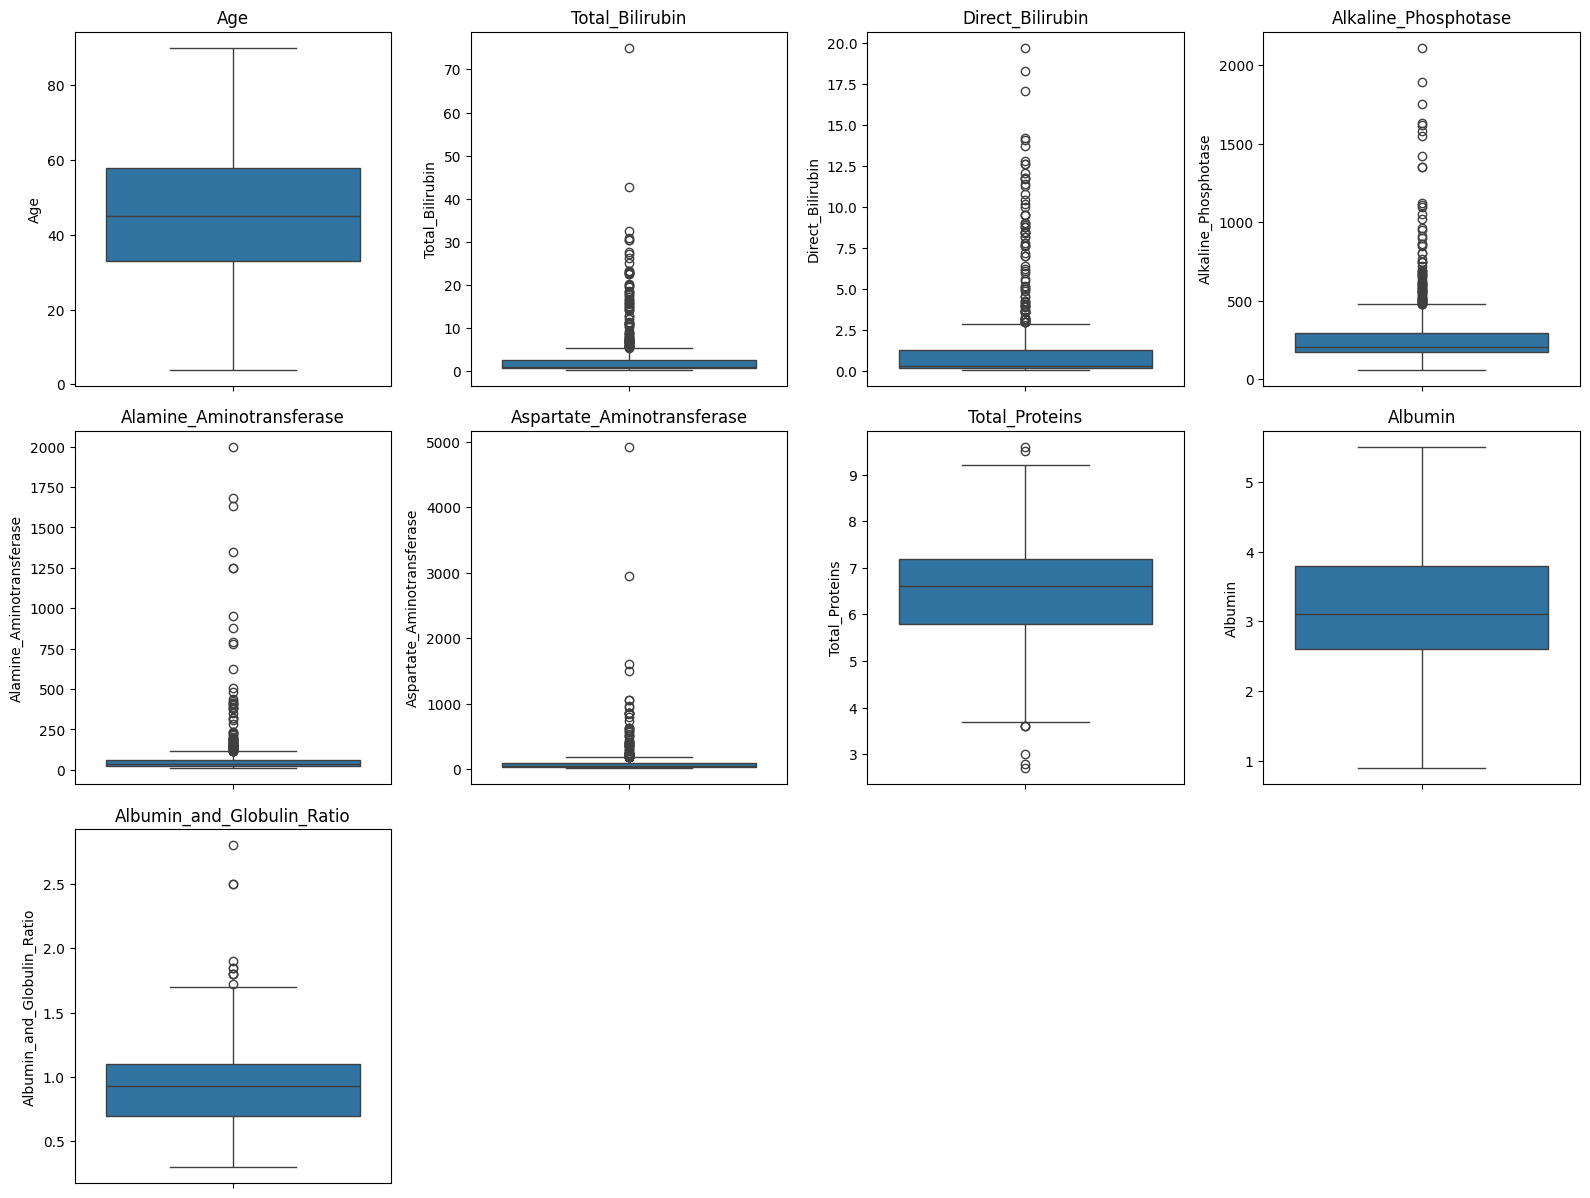

In [16]:
## Boxplot for ALL Columns
plt.figure(figsize=(16, 24))

for i, col in enumerate(num_cols, 1):
    plt.subplot(6, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


In [17]:
## Outlier Removal using IQR
def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    data[column] = np.where(
        data[column] < lower, lower,
        np.where(data[column] > upper, upper, data[column])
    )
for col in num_cols:
    cap_outliers_iqr(df, col)



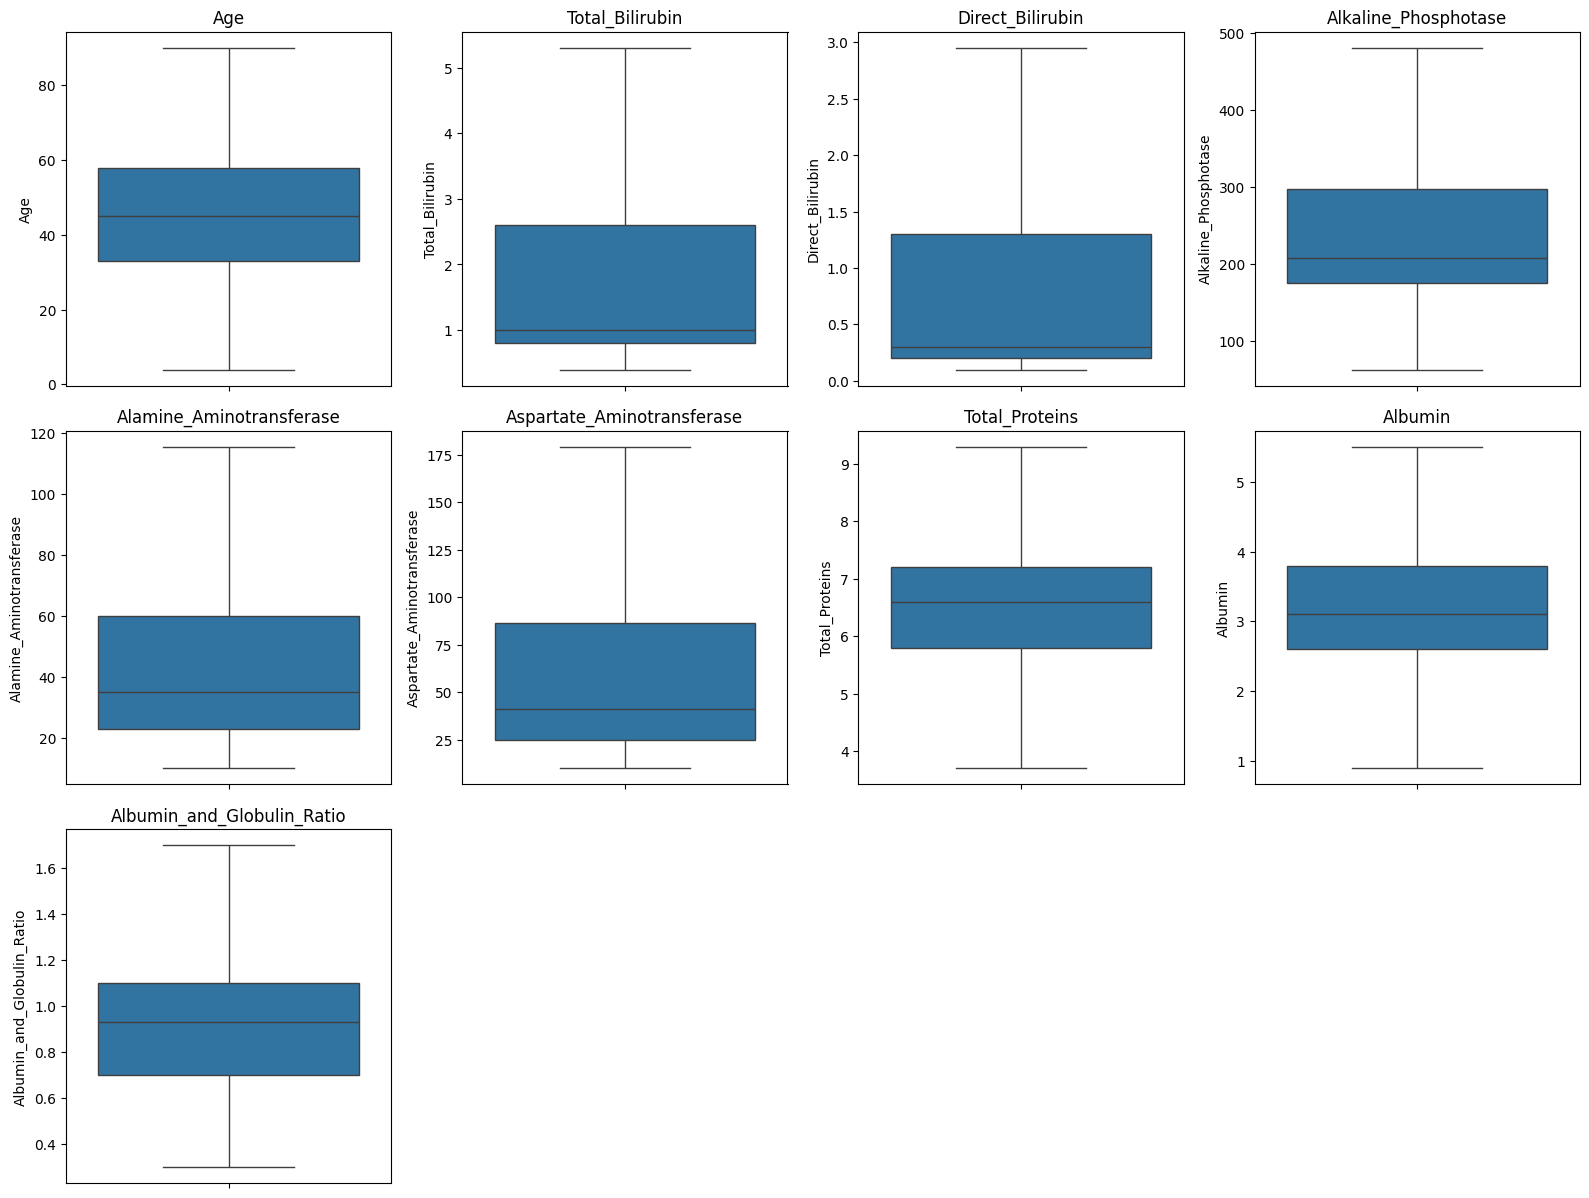

In [18]:
## Verify After Outlier Treatment
plt.figure(figsize=(16, 24))

for i, col in enumerate(num_cols, 1):
    plt.subplot(6, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()



### Histogram Plot

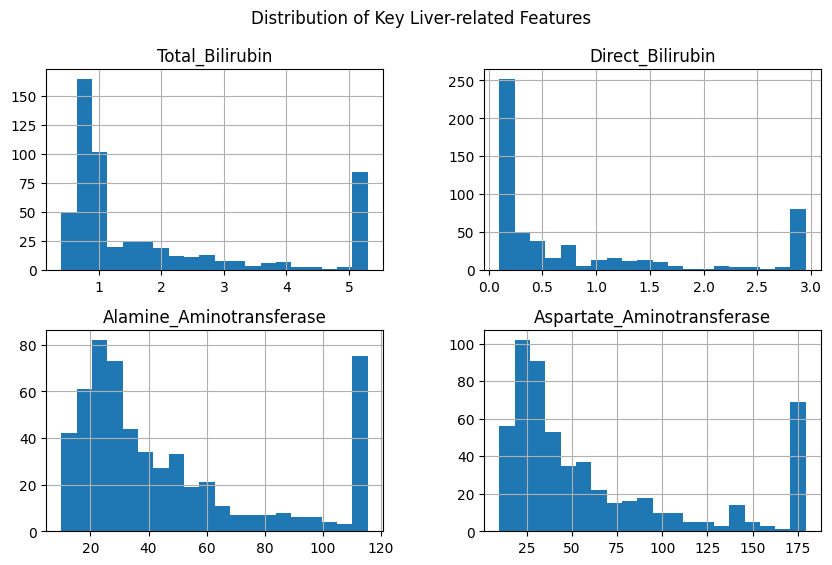

In [19]:
df[['Total_Bilirubin', 'Direct_Bilirubin', 
    'Alamine_Aminotransferase', 'Aspartate_Aminotransferase']].hist(
    bins=20, figsize=(10,6)
)
plt.suptitle("Distribution of Key Liver-related Features")
plt.show()


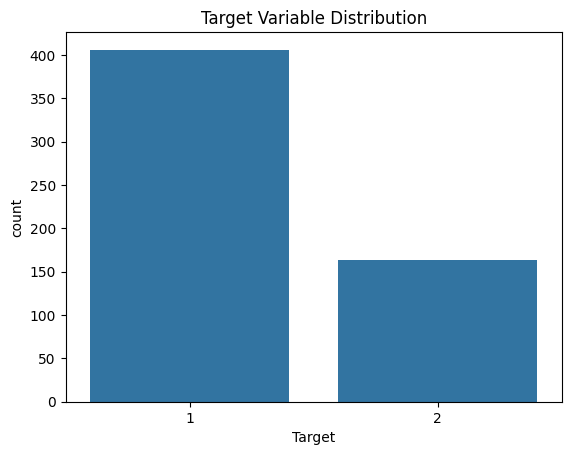

In [20]:
sns.countplot(x='Target', data=df)
plt.title("Target Variable Distribution")
plt.show()


### Histogram Analysis Summary 
Histograms confirm strong right skewness in bilirubin and enzyme features, supporting the choice of IQR-based outlier treatment. The target distribution remains unchanged after preprocessing, ensuring no class bias is introduced.


## Exploratory Data Analysis (EDA) Observations
1) Total Bilirubin and Direct Bilirubin show strong right skew, indicating the presence of extreme medical values.
2) Liver enzyme features such as Alamine Aminotransferase and Aspartate Aminotransferase contain multiple outliers, which is expected in clinical data.
3) After applying IQR-based capping, the distributions became more compact without removing patient records.
4) The target variable distribution remained unchanged after outlier treatment, ensuring no bias was introduced.
   

### Additional EDA Insights
Histogram analysis of key liver-related features shows strong right skewness in bilirubin and enzyme attributes, which is common in clinical datasets. This observation supports the use of IQR-based capping rather than outlier removal.

The target variable distribution shows a higher proportion of liver disease cases, confirming class imbalance. This imbalance motivated the use of SMOTE during model training.

### EDA Summary Insights

Exploratory Data Analysis revealed that bilirubin-related features exhibit strong right skewness, indicating the presence of extreme clinical values. Liver enzyme features such as Alamine Aminotransferase and Aspartate Aminotransferase show multiple high-value outliers, which is expected in patients with liver dysfunction.

Boxplots confirmed that these extreme values are not data errors but clinically meaningful variations. Therefore, instead of removing records, IQR-based capping was chosen to reduce the influence of extreme values while preserving patient information.

The target variable shows a clear class imbalance, with liver disease cases forming the majority class. This insight directly influenced the later decision to apply SMOTE during model training.


## Encode Categorical Variable (Gender)

In [21]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})


In [22]:
df['Gender'].value_counts()


Gender
1    430
0    140
Name: count, dtype: int64

## Check Class Balance

In [23]:
df['Target'].value_counts()

Target
1    406
2    164
Name: count, dtype: int64

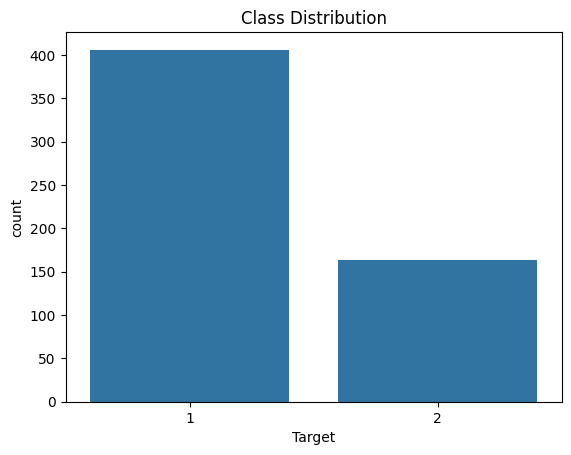

In [24]:
sns.countplot(x='Target', data=df)
plt.title('Class Distribution')
plt.show()


## Split Features & Target

In [25]:
X = df.drop(columns=['Target'])
y = df['Target']


In [26]:
## Train–Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [27]:
X_train

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio
73,52.0,1,0.6,0.10,171.0,22.0,16.0,6.6,3.6,1.2
194,49.0,1,2.0,0.60,209.0,48.0,32.0,5.7,3.0,1.1
68,66.0,1,0.7,0.20,239.0,27.0,26.0,6.3,3.7,1.4
169,60.0,1,5.3,2.95,481.0,33.0,32.0,6.8,3.1,0.8
65,57.0,1,1.4,0.70,470.0,62.0,88.0,5.6,2.5,0.8
...,...,...,...,...,...,...,...,...,...,...
76,31.0,1,0.9,0.20,481.0,115.5,17.0,5.3,2.3,0.7
113,74.0,1,0.6,0.10,272.0,24.0,98.0,5.0,2.0,0.6
283,18.0,1,1.3,0.70,316.0,10.0,21.0,6.0,2.1,0.5
448,48.0,0,0.8,0.20,142.0,26.0,25.0,6.0,2.6,0.7


In [28]:
y_train

73     1
194    2
68     1
169    1
65     1
      ..
76     1
113    1
283    2
448    1
109    2
Name: Target, Length: 456, dtype: int64

In [29]:
## Feature Scaling 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Preprocessing Summary 
1) The IQR method was used for outlier treatment as medical data often contains extreme values, and removing records could result in loss of important clinical information.
2) Feature scaling was applied using StandardScaler because distance-based algorithms such as KNN and SVM are sensitive to differences in feature magnitude.
3) A stratified train-test split was performed to preserve class distribution in both training and testing sets.
4) Since all features in the dataset are numerical, no categorical encoding was required, simplifying the preprocessing process.

### Preprocessing Consistency Explanation
Baseline models were trained on the original imbalanced dataset to observe inherent data behavior. Advanced and tuned models were trained on SMOTE-balanced data with consistent feature scaling applied to the resampled training set and the original test set. This ensures fair evaluation while preserving baseline comparison.

## Baseline Machine Learning Models


In [30]:
## Logistic Regression Model
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)


In [31]:
## Logistic Regression Evaluation
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7543859649122807
              precision    recall  f1-score   support

           1       0.81      0.88      0.84        85
           2       0.52      0.38      0.44        29

    accuracy                           0.75       114
   macro avg       0.67      0.63      0.64       114
weighted avg       0.73      0.75      0.74       114



In [32]:
## K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

In [33]:
## K-Nearest Neighbors (KNN) Evaluation
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.6578947368421053
              precision    recall  f1-score   support

           1       0.77      0.78      0.77        85
           2       0.32      0.31      0.32        29

    accuracy                           0.66       114
   macro avg       0.54      0.54      0.54       114
weighted avg       0.65      0.66      0.66       114



In [34]:
## Naive Bayes (NB)
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)


In [35]:
## Naive Bayes (NB) Evaluation

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.5789473684210527
              precision    recall  f1-score   support

           1       0.88      0.51      0.64        85
           2       0.35      0.79      0.49        29

    accuracy                           0.58       114
   macro avg       0.62      0.65      0.57       114
weighted avg       0.74      0.58      0.60       114



## Baseline Machine Learning Models Summary
1) Dataset is imbalanced
2) Logistic Regression performs consistently
3) Naive Bayes is fast but assumes independence
4) KNN performance is moderate
5) Advanced models required for better performance


## SMOTE Analysis

In [36]:
!pip install -U imbalanced-learn


Defaulting to user installation because normal site-packages is not writeable


In [37]:
## Apply SMOTE only on training data 
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


In [38]:
pd.Series(y_train_res).value_counts()


Target
1    321
2    321
Name: count, dtype: int64

In [39]:
## Feature Scaling (After SMOTE) because the data is balanced
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)


## Advanced  Machine Models

In [40]:
## Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)


In [41]:
## Decision Tree Evaluation
from sklearn.metrics import accuracy_score, classification_report

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.5789473684210527
              precision    recall  f1-score   support

           1       0.77      0.62      0.69        85
           2       0.29      0.45      0.35        29

    accuracy                           0.58       114
   macro avg       0.53      0.54      0.52       114
weighted avg       0.65      0.58      0.60       114



In [42]:
## Random forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)

In [43]:
## Random Forest Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.6842105263157895
              precision    recall  f1-score   support

           1       0.85      0.71      0.77        85
           2       0.42      0.62      0.50        29

    accuracy                           0.68       114
   macro avg       0.63      0.66      0.63       114
weighted avg       0.74      0.68      0.70       114



In [44]:
## Support Vector Machine (SVM)
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

svm.fit(X_train_res_scaled, y_train_res)

y_pred_svm = svm.predict(X_test_scaled)

In [45]:
## Support Vector Machine (SVM) Evaluation
from sklearn.metrics import accuracy_score, classification_report

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.6578947368421053
              precision    recall  f1-score   support

           1       0.88      0.62      0.73        85
           2       0.41      0.76      0.53        29

    accuracy                           0.66       114
   macro avg       0.65      0.69      0.63       114
weighted avg       0.76      0.66      0.68       114



In [46]:
## Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train_res, y_train_res)

y_pred_gb = gb.predict(X_test)

In [47]:
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.6842105263157895
              precision    recall  f1-score   support

           1       0.81      0.75      0.78        85
           2       0.40      0.48      0.44        29

    accuracy                           0.68       114
   macro avg       0.61      0.62      0.61       114
weighted avg       0.71      0.68      0.69       114



## Overfitting Check and Hyperparameter tuning 

In [48]:
train_pred_rf = rf.predict(X_train_res)
train_acc_rf = accuracy_score(y_train_res, train_pred_rf)

test_acc_rf = accuracy_score(y_test, y_pred_rf)

print("RF Training Accuracy:", train_acc_rf)
print("RF Testing Accuracy :", test_acc_rf)


RF Training Accuracy: 0.9735202492211839
RF Testing Accuracy : 0.6842105263157895


In [49]:
## Hyperparameter for Decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(random_state=42)

dt_params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(
    dt,
    dt_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

dt_grid.fit(X_train_res, y_train_res)


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [50]:
best_dt = dt_grid.best_estimator_
print("Best DT Params:", best_dt)


Best DT Params: DecisionTreeClassifier(min_samples_leaf=4, min_samples_split=10,
                       random_state=42)


In [51]:
y_pred_dt_tuned = best_dt.predict(X_test)

print("Decision Tree Tuned Accuracy:", accuracy_score(y_test, y_pred_dt_tuned))
print(classification_report(y_test, y_pred_dt_tuned))

Decision Tree Tuned Accuracy: 0.6491228070175439
              precision    recall  f1-score   support

           1       0.82      0.68      0.74        85
           2       0.37      0.55      0.44        29

    accuracy                           0.65       114
   macro avg       0.59      0.62      0.59       114
weighted avg       0.70      0.65      0.67       114



In [52]:
## Hyperparameter Tuning Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train_res, y_train_res)


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [53]:
best_rf = rf_grid.best_estimator_
print("Best RF Params:", rf_grid.best_params_)


Best RF Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [54]:
y_pred_rf_tuned = best_rf.predict(X_test)

print("Random Forest Tuned Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))
print(classification_report(y_test, y_pred_rf_tuned))


Random Forest Tuned Accuracy: 0.7105263157894737
              precision    recall  f1-score   support

           1       0.83      0.76      0.80        85
           2       0.44      0.55      0.49        29

    accuracy                           0.71       114
   macro avg       0.64      0.66      0.64       114
weighted avg       0.73      0.71      0.72       114



In [55]:
## Hyperparameter Tuning SVM
from sklearn.svm import SVC

svm = SVC()

svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    svm,
    svm_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

svm_grid.fit(X_train_res_scaled, y_train_res)


,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [56]:
best_svm = svm_grid.best_estimator_
print("Best SVM Params:", svm_grid.best_params_)


Best SVM Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [57]:
y_pred_svm_tuned = best_svm.predict(X_test_scaled)

print("SVM Tuned Accuracy:", accuracy_score(y_test, y_pred_svm_tuned))
print(classification_report(y_test, y_pred_svm_tuned))


SVM Tuned Accuracy: 0.6754385964912281
              precision    recall  f1-score   support

           1       0.88      0.66      0.75        85
           2       0.42      0.72      0.53        29

    accuracy                           0.68       114
   macro avg       0.65      0.69      0.64       114
weighted avg       0.76      0.68      0.70       114



In [58]:
## Hyperparameter Tuning Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb_params = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4]
}

gb_grid = GridSearchCV(
    gb,
    gb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

gb_grid.fit(X_train_res, y_train_res)


,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [100, 150, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [59]:
best_gb = gb_grid.best_estimator_
print("Best GB Params:", gb_grid.best_params_)


Best GB Params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 150}


In [60]:
y_pred_gb_tuned = best_gb.predict(X_test)

print("Gradient Boosting Tuned Accuracy:", accuracy_score(y_test, y_pred_gb_tuned))
print(classification_report(y_test, y_pred_gb_tuned))


Gradient Boosting Tuned Accuracy: 0.6491228070175439
              precision    recall  f1-score   support

           1       0.75      0.79      0.77        85
           2       0.28      0.24      0.26        29

    accuracy                           0.65       114
   macro avg       0.52      0.51      0.51       114
weighted avg       0.63      0.65      0.64       114



## Feature Importance Analysis

In [61]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance


,Feature,Importance
2,Total_Bilirubin,0.134128
5,Alamine_Aminotransferase,0.132961
4,Alkaline_Phosphotase,0.130696
6,Aspartate_Aminotransferase,0.116665
3,Direct_Bilirubin,0.110974
9,Albumin_and_Globulin_Ratio,0.103146
0,Age,0.087573
8,Albumin,0.083528
7,Total_Proteins,0.083397
1,Gender,0.016931


## Feature Importance
1) Liver enzymes such as Alamine Aminotransferase and Aspartate Aminotransferase were the most influential features.
2) Bilirubin levels also played a significant role in predicting liver disease
3) These features are clinically relevant, aligning well with real-world medical understanding.
4) The feature importance analysis adds business and healthcare interpretability to the model.

In [62]:
## Final Comparsion Model 
final_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Naive Bayes",
        "Decision Tree",
        "Decision Tree (Tuned)",
        "Random Forest (Tuned)",
        "SVM (Tuned)",
        "Gradient Boosting (Tuned)"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_dt_tuned),
        accuracy_score(y_test, y_pred_rf_tuned),
        accuracy_score(y_test, y_pred_svm_tuned),
        accuracy_score(y_test, y_pred_gb_tuned)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_lr, pos_label=1),
        recall_score(y_test, y_pred_knn, pos_label=1),
        recall_score(y_test, y_pred_nb, pos_label=1),
        recall_score(y_test, y_pred_dt, pos_label=1),
        recall_score(y_test, y_pred_dt_tuned, pos_label=1),
        recall_score(y_test, y_pred_rf_tuned, pos_label=1),
        recall_score(y_test, y_pred_svm_tuned, pos_label=1),
        recall_score(y_test, y_pred_gb_tuned, pos_label=1)
    ],
    
    "F1-Score": [
        f1_score(y_test, y_pred_lr, pos_label=1),
        f1_score(y_test, y_pred_knn, pos_label=1),
        f1_score(y_test, y_pred_nb, pos_label=1),
        f1_score(y_test, y_pred_dt, pos_label=1),
        f1_score(y_test, y_pred_dt_tuned, pos_label=1),
        f1_score(y_test, y_pred_rf_tuned, pos_label=1),
        f1_score(y_test, y_pred_svm_tuned, pos_label=1),
        f1_score(y_test, y_pred_gb_tuned, pos_label=1)
    ]
})

final_model_comparison


,Model,Accuracy,Recall,F1-Score
0,Logistic Regression,0.754386,0.882353,0.842697
1,KNN,0.657895,0.776471,0.771930
2,Naive Bayes,0.578947,0.505882,0.641791
3,Decision Tree,0.578947,0.623529,0.688312
4,Decision Tree (Tuned),0.649123,0.682353,0.743590
5,Random Forest (Tuned),0.710526,0.764706,0.797546
6,SVM (Tuned),0.675439,0.658824,0.751678
7,Gradient Boosting (Tuned),0.649123,0.788235,0.770115


## Final Model Selection (Overall)

## Challenges Faced

## How Challenges Were Handled

## Project Summary & Conclusion

## Final Model Selection
Among all tuned models, the Random Forest classifier achieved the highest F1-score and recall for liver disease prediction and is selected as the final model. Its superior performance is due to its ability to capture non-linear relationships among clinical features, unlike Logistic Regression which assumes linearity.

Future work may focus on validating the model on a larger multi-center dataset and exploring explainable AI techniques to further enhance clinical trust.
